# 2.3 Variational data assimilation in ~20 lines

Data assimilation answers a different question from calibration: not *what are the
model's parameters*, but *what is the state of the system right now*, given a model and
a stream of incomplete, noisy observations. Four-dimensional variational assimilation
(**4D-Var**) does this by searching for the initial state whose model trajectory best
fits all observations in a time window — and it is the historical point of contact
between this book's two worlds. Operational centers adopted 4D-Var in the 1990s
{cite}`talagrand1987variational`, and the price of admission was the hand-built adjoint
model needed to compute the gradient of the fit. That price is what `jax.grad`
eliminates.

The control variable is the initial temperature profile $T_0$ (60 numbers). The cost
function is the standard two-term form,

$$J(T_0) = \tfrac{1}{2}\,\sum_j \frac{(T_0 - T^b)_j^2}{\sigma_b^2}
\;+\; \tfrac{1}{2} \sum_{k}
\frac{\bigl(H_k\,M_{t_k}(T_0) - y_k\bigr)^2}{\sigma_o^2},$$

where $T^b$ is the *background* (the prior estimate — here, climatology), $M_{t_k}$ is
the model integrated to observation time $t_k$, $H_k$ selects the observed latitudes,
and $y_k$ are the observations. The background term regularizes the problem: with only
5 observed latitudes and 60 unknowns, the data alone cannot determine the state.

```{admonition} Learning goals
:class: tip
- Write the 4D-Var cost function for the Budyko–Sellers model
- Recognize `jax.grad` of that cost as exactly the adjoint method
- Recover an initial-condition anomaly from sparse, noisy observations
- Diagnose how observation coverage shapes the analysis error
```

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

In [2]:
# --- The Budyko-Sellers model (defined in Chapter 2.1; repeated so this notebook is self-contained)
N_LAT = 60
x_edge = jnp.linspace(-1.0, 1.0, N_LAT + 1)      # cell edges in x = sin(latitude)
x = 0.5 * (x_edge[:-1] + x_edge[1:])             # cell centres (an equal-area grid)
dx = 2.0 / N_LAT
lat = jnp.rad2deg(jnp.arcsin(x))                 # centre latitudes (degrees)

Q = 340.25              # global-mean insolation S0/4, W m^-2
s_x = 1.0 - 0.482 * 0.5 * (3.0 * x**2 - 1.0)     # annual-mean insolation shape s(x)
A_olr = 203.3           # outgoing longwave radiation at 0 degC, W m^-2
B_olr = 2.09            # longwave feedback, W m^-2 K^-1
heat_capacity = 4.0e7   # J m^-2 K^-1 (~10 m of water)
dt = 21600.0            # 6-hour time step, s

default_params = {"D": 0.48, "albedo_warm": 0.32, "albedo_ice": 0.62}

def albedo(T, p):
    ice_fraction = 0.5 * (1.0 - jnp.tanh((T + 10.0) / 2.0))    # ice below about -10 degC
    return p["albedo_warm"] + (p["albedo_ice"] - p["albedo_warm"]) * ice_fraction

def energy_tendency(T, p, forcing=0.0):
    """Net energy input at each latitude (W m^-2), for temperature T in degC."""
    absorbed = Q * s_x * (1.0 - albedo(T, p))
    emitted = A_olr + B_olr * T
    flux = p["D"] * (1.0 - x_edge[1:-1] ** 2) * jnp.diff(T) / dx   # poleward heat flux
    flux = jnp.concatenate([jnp.zeros(1), flux, jnp.zeros(1)])     # no flux through the poles
    transport = jnp.diff(flux) / dx
    return absorbed - emitted + transport + forcing

def integrate(T0, p, forcing=0.0, n_years=30):
    """Step the model forward and return the final temperature profile."""
    n_steps = int(n_years * 365.25 * 86400 / dt)
    def step(T, _):
        return T + dt / heat_capacity * energy_tendency(T, p, forcing), None
    T_final, _ = jax.lax.scan(step, T0, None, length=n_steps)
    return T_final

T_start = 15.0 - 25.0 * 0.5 * (3.0 * x**2 - 1.0)    # smooth warm initial profile

## The twin experiment

Assimilation methods are tested by *twin experiments*: invent a truth, observe it
imperfectly, try to recover it. The truth here is the equilibrium climate plus a
smooth initial anomaly (warm in the northern mid-latitudes, cool in the southern
tropics). Observations: 5 latitudes, once every 30 days for a year, 0.5 K noise —
sparse in space and time, as real networks are:

In [3]:
T_clim = integrate(T_start, default_params)          # climatology = background

steps_per_day = int(86400 / dt)
def trajectory(T0, n_days=360):
    """Daily temperature fields for n_days."""
    def one_day(T, _):
        T, _ = jax.lax.scan(lambda t, __: (t + dt / heat_capacity
                                           * energy_tendency(t, default_params), None),
                            T, None, length=steps_per_day)
        return T, T
    _, days = jax.lax.scan(one_day, T0, None, length=n_days)
    return days

anomaly = (6.0 * jnp.exp(-((lat - 45.0) / 20.0) ** 2)
           - 4.0 * jnp.exp(-((lat + 30.0) / 25.0) ** 2))
T0_true = T_clim + anomaly

obs_lats = jnp.array([-60.0, -30.0, 0.0, 30.0, 60.0])
obs_idx = jnp.array([jnp.argmin(jnp.abs(lat - l)) for l in obs_lats])
obs_days = jnp.arange(29, 360, 30)                   # 12 observation times

key = jax.random.key(1)
sigma_obs = 0.5
truth_traj = trajectory(T0_true)
y_obs = truth_traj[obs_days][:, obs_idx] \
        + sigma_obs * jax.random.normal(key, (len(obs_days), len(obs_idx)))
print(f"unknowns: {N_LAT}; observations: {y_obs.size}")

unknowns: 60; observations: 60


## The whole method

Cost function, gradient, descent. The gradient of the observation term with respect to
$T_0$ is mathematically the adjoint model applied to the observation misfits — the
computation entire agencies once maintained by hand, here produced by one call:

In [4]:
import optax

sigma_b = 5.0
T_background = T_clim

def cost(T0):
    traj = trajectory(T0)
    J_background = 0.5 * jnp.sum(((T0 - T_background) / sigma_b) ** 2)
    J_obs = 0.5 * jnp.sum(((traj[obs_days][:, obs_idx] - y_obs) / sigma_obs) ** 2)
    return J_background + J_obs

opt = optax.adam(optax.exponential_decay(0.5, transition_steps=100, decay_rate=0.5))
T0_hat = T_background
state = opt.init(T0_hat)
value_and_grad = jax.jit(jax.value_and_grad(cost))
for i in range(300):
    J, g = value_and_grad(T0_hat)
    updates, state = opt.update(g, state)
    T0_hat = optax.apply_updates(T0_hat, updates)

rmse = lambda a: float(jnp.sqrt(jnp.mean((a - T0_true) ** 2)))
print(f"initial-state RMSE:  background {rmse(T_background):.2f} K  ->  analysis {rmse(T0_hat):.2f} K")

initial-state RMSE:  background 3.02 K  ->  analysis 1.33 K


Twenty-ish lines, as promised. The *analysis* (the assimilation community's word for
the estimate) more than halves the initial-state error, using observations of five
latitudes to correct all sixty — the model's physics performs the interpolation,
spreading information along the dynamics. Where the information does and does not
reach is the interesting part:

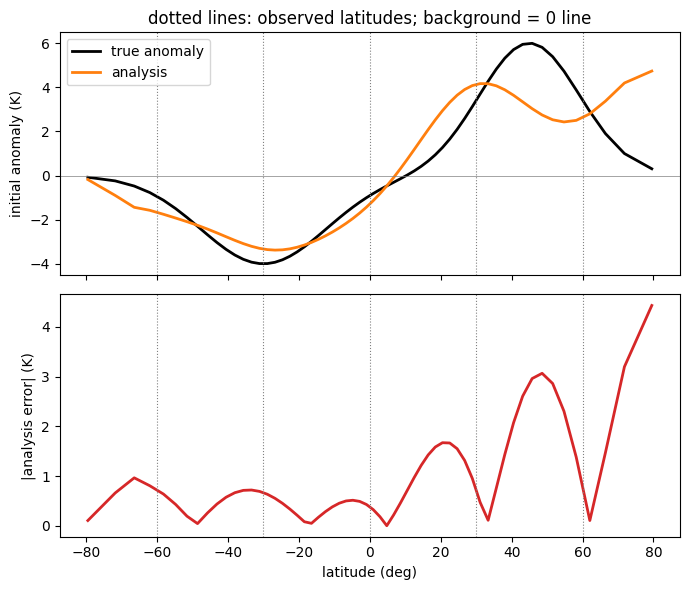

mean error at observed latitudes: 0.79 K


mean error poleward of 70 deg:    2.10 K


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax1.plot(lat, T0_true - T_clim, "k", lw=2, label="true anomaly")
ax1.plot(lat, T0_hat - T_clim, "C1", lw=2, label="analysis")
ax1.axhline(0, color="gray", lw=0.5)
for l in obs_lats:
    ax1.axvline(l, color="gray", ls=":", lw=0.8)
ax1.set_ylabel("initial anomaly (K)"); ax1.legend()
ax1.set_title("dotted lines: observed latitudes; background = 0 line")

ax2.plot(lat, jnp.abs(T0_hat - T0_true), "C3", lw=2)
for l in obs_lats:
    ax2.axvline(l, color="gray", ls=":", lw=0.8)
ax2.set_xlabel("latitude (deg)"); ax2.set_ylabel("|analysis error| (K)")
plt.tight_layout(); plt.show()

err = jnp.abs(T0_hat - T0_true)
print(f"mean error at observed latitudes: {float(jnp.mean(err[obs_idx])):.2f} K")
print(f"mean error poleward of 70 deg:    {float(jnp.mean(err[jnp.abs(lat) > 70])):.2f} K")

The analysis tracks the anomaly closely near observed latitudes and relaxes toward
the background where no information arrives — the poles, which no observation
constrains and which diffusion only weakly connects to observed regions, retain most
of their error. This spatial structure *is* the observing network, made visible.

## What operational 4D-Var adds

The method above is 4D-Var stripped to its skeleton. Operational systems add
machinery that matters at scale but changes nothing conceptual: flow-dependent
background error *covariances* in place of the scalar $\sigma_b$ (so a correction at
one point propagates to dynamically related points), an incremental formulation that
linearizes around a high-resolution trajectory, model-error terms (weak-constraint
4D-Var), and preconditioned minimizers in place of Adam. Every one of those pieces
still needs the gradient — which is why a differentiable model makes the entire family
of variational methods available essentially for free.

**Exercises.**
1. Estimate parameters and state jointly: add $D$ to the control variables with an
   appropriate background term. Does the anomaly recovery improve or degrade?
2. Move all five observation sites into the Northern Hemisphere. What happens to the
   southern anomaly, and to the *northern* analysis error?
3. Set $\sigma_b = 100$ (an effectively useless background). Where does the analysis
   go wrong, and why is the problem now under-determined?